# Forward PINN

## Import Dependencies

In [472]:
import random
from pathlib import Path
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Random State & Device Initialization

In [473]:
SEED = 42


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)

In [474]:
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(f"Device: {device}")

Device: cpu


## Formatting

In [475]:
PLOT_DPI = 165

COLORS = {
    "train": "#2563EB",
    "valid": "#F97316",
    "test": "#16A34A",
    "adam": "#2563EB",
    "lbfgs": "#9333EA",
    "data": "#0EA5E9",
    "physics": "#DC2626",
    "reflection": "#16A34A",
    "ideal": "#111827",
    "gray": "#6B7280",
    "light_gray": "#E5E7EB",
    "purple": "#7C3AED",
    "amber": "#F59E0B",
}

SPLIT_COLORS = {
    "train": COLORS["train"],
    "valid": COLORS["valid"],
    "test": COLORS["test"],
}

plt.rcParams.update({
    "figure.figsize": (7.2, 4.4),
    "figure.dpi": PLOT_DPI,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11.5,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titleweight": "semibold",
    "axes.labelcolor": "#111827",
    "xtick.color": "#374151",
    "ytick.color": "#374151",
    "axes.edgecolor": "#D1D5DB",
    "axes.linewidth": 0.9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.8,
    "grid.color": "#9CA3AF",
    "lines.linewidth": 2.1,
    "legend.frameon": True,
    "legend.framealpha": 0.94,
    "legend.edgecolor": "#E5E7EB",
})


def polish_axes(
    ax,
    title: str | None = None,
    xlabel: str | None = None,
    ylabel: str | None = None,
    legend: bool = False,
) -> None:
    if title is not None:
        ax.set_title(title, pad=11)
    if xlabel is not None:
        ax.set_xlabel(xlabel, labelpad=7)
    if ylabel is not None:
        ax.set_ylabel(ylabel, labelpad=7)

    ax.grid(True, alpha=0.22, linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.7)
    ax.spines["bottom"].set_alpha(0.7)
    ax.tick_params(axis="both", which="major", length=4, width=0.8, color="#6B7280")

    if legend:
        leg = ax.legend()
        if leg is not None:
            leg.get_frame().set_facecolor("white")
            leg.get_frame().set_edgecolor("#E5E7EB")
            leg.get_frame().set_linewidth(0.9)
            leg.get_frame().set_alpha(0.95)


def smooth_series(values, window: int = 35) -> np.ndarray:
    return pd.Series(values).rolling(window=window, min_periods=1, center=False).mean().to_numpy()


def log10_safe(values, eps: float = 1e-16) -> np.ndarray:
    return np.log10(np.asarray(values).clip(min=eps))


def plot_density_hist(
    ax,
    values,
    *,
    bins: int = 80,
    color: str,
    label: str,
    alpha: float = 0.20,
    linewidth: float = 2.2,
) -> None:
    ax.hist(
        values,
        bins=bins,
        density=True,
        histtype="stepfilled",
        alpha=alpha,
        color=color,
        edgecolor=color,
        linewidth=1.0,
        label=label,
    )
    ax.hist(
        values,
        bins=bins,
        density=True,
        histtype="step",
        color=color,
        linewidth=linewidth,
    )


def plot_ecdf(
    ax,
    values,
    *,
    color: str,
    label: str,
    linewidth: float = 2.2,
) -> None:
    x = np.sort(np.asarray(values))
    y = np.linspace(0.0, 1.0, len(x), endpoint=True)
    ax.plot(x, y, color=color, linewidth=linewidth, label=label)


def compact_count(n: int) -> str:
    n = int(n)
    if n % 1000 == 0:
        return f"{n // 1000}k"
    return str(n)


def compact_float(value: float) -> str:
    value = float(value)
    if value == 0:
        return "0"
    if abs(value - round(value)) < 1e-12:
        return str(int(round(value)))
    text = f"{value:g}"
    return text.replace(".", "p").replace("-", "m").replace("+", "")

## Configuration

In [476]:
@dataclass(frozen=True)
class Config:
    notebook_dir: Path = Path.cwd()
    project_root: Path = notebook_dir.parent if notebook_dir.name.lower() == "pinn" else notebook_dir

    data_path: Path = project_root / "storage" / "dataset_10k.csv"
    saved_models_dir: Path = (
        notebook_dir / "saved_models"
        if notebook_dir.name.lower() == "pinn"
        else project_root / "PINN" / "saved_models"
    )

    load_existing_model: bool = True
    model_checkpoint_path: Path | None = Path("saved_models/noise_3/forward_N10k_h128x4_bs256_ep2000_lr0p001_phys1_R0p3.pt")
    save_model_after_training: bool = True

    omega0: float = 2.0 * np.pi * 100.0
    period_a: float = 0.05

    min_R: float = 0.0
    max_R: float = 1.0

    add_noise: bool = True
    noise_level: float = 0.05
    noise_seed: int = 42

    test_size: float = 0.15
    valid_size: float = 0.15
    n_strat_bins: int = 10

    batch_size: int = 256
    max_epochs: int = 2000
    learning_rate: float = 1.0e-3
    weight_decay: float = 1.0e-5

    use_lbfgs: bool = True
    lbfgs_lr: float = 1.0
    lbfgs_max_iter: int = 5000
    lbfgs_max_eval: int = 7500
    lbfgs_history_size: int = 100
    lbfgs_tolerance_grad: float = 1.0e-9
    lbfgs_tolerance_change: float = 1.0e-11
    lbfgs_log_every: int = 10
    lbfgs_valid_log_every: int = 25

    lambda_phys: float = 1.0
    lambda_R: float = 0.3

    patience: int = 250
    min_delta: float = 1.0e-7

    hidden_dim: int = 128
    num_hidden_layers: int = 4
    dropout: float = 0.0

    plot_sample_size: int = 10_000
    relative_error_min_R: float = 1.0e-4


cfg = Config()

print("Current directory:", Path.cwd())
print("Dataset path:", cfg.data_path)
print("Saved models root:", cfg.saved_models_dir)
print(cfg)

Current directory: c:\Users\IlyaApokorin\Reflection-Coefficient-PINN\PINN
Dataset path: c:\Users\IlyaApokorin\Reflection-Coefficient-PINN\storage\dataset_10k.csv
Saved models root: c:\Users\IlyaApokorin\Reflection-Coefficient-PINN\PINN\saved_models
Config(notebook_dir=WindowsPath('c:/Users/IlyaApokorin/Reflection-Coefficient-PINN/PINN'), project_root=WindowsPath('c:/Users/IlyaApokorin/Reflection-Coefficient-PINN'), data_path=WindowsPath('c:/Users/IlyaApokorin/Reflection-Coefficient-PINN/storage/dataset_10k.csv'), saved_models_dir=WindowsPath('c:/Users/IlyaApokorin/Reflection-Coefficient-PINN/PINN/saved_models'), load_existing_model=True, model_checkpoint_path=WindowsPath('saved_models/noise_3/forward_N10k_h128x4_bs256_ep2000_lr0p001_phys1_R0p3.pt'), save_model_after_training=True, omega0=628.3185307179587, period_a=0.05, min_R=0.0, max_R=1.0, add_noise=True, noise_level=0.05, noise_seed=42, test_size=0.15, valid_size=0.15, n_strat_bins=10, batch_size=256, max_epochs=2000, learning_rate

## Data Loading

In [477]:
df = pd.read_csv(cfg.data_path)

required_columns = [
    "omega", "psi", "delta_x", "delta_y", "kappa",
    "Re_mu", "Im_mu",
    "Re_S", "Im_S", "Re_S1", "Im_S1", "Re_S2", "Im_S2",
    "Re_zeta1", "Im_zeta1", "Re_zeta2", "Im_zeta2",
    "R", "T",
]

missing = sorted(set(required_columns) - set(df.columns))
if missing:
    raise ValueError()

finite_mask = np.ones(len(df), dtype=bool)
for col in required_columns:
    finite_mask &= np.isfinite(df[col].to_numpy())

if not finite_mask.all():
    bad_count = int((~finite_mask).sum())
    raise ValueError()

R_mask = (df["R"] >= cfg.min_R) & (df["R"] <= cfg.max_R)
if not R_mask.all():
    bad_count = int((~R_mask).sum())
    raise ValueError()

n_objects = len(df)
n_objects_tag = compact_count(n_objects)

noise_percent = int(round((cfg.noise_level if cfg.add_noise else 0.0) * 100))
noise_dir = cfg.saved_models_dir / f"noise_{noise_percent}"
noise_dir.mkdir(parents=True, exist_ok=True)

model_name = (
    f"forward_N{n_objects_tag}_"
    f"h{cfg.hidden_dim}x{cfg.num_hidden_layers}_"
    f"bs{cfg.batch_size}_ep{cfg.max_epochs}_"
    f"lr{compact_float(cfg.learning_rate)}_"
    f"phys{compact_float(cfg.lambda_phys)}_R{compact_float(cfg.lambda_R)}.pt"
)
model_path = noise_dir / model_name
checkpoint_path = Path(cfg.model_checkpoint_path) if cfg.model_checkpoint_path is not None else model_path

print(f"Loaded rows: {n_objects}")
print(f"Columns: {len(df.columns)}")
print(f"Model path: {model_path}")
print(f"Checkpoint path: {checkpoint_path}")

display(df.head())


Loaded rows: 10000
Columns: 25
Model path: c:\Users\IlyaApokorin\Reflection-Coefficient-PINN\PINN\saved_models\noise_5\forward_N10k_h128x4_bs256_ep2000_lr0p001_phys1_R0p3.pt
Checkpoint path: saved_models\noise_3\forward_N10k_h128x4_bs256_ep2000_lr0p001_phys1_R0p3.pt


,omega,psi,delta_x,delta_y,kappa,Re_mu,Im_mu,Re_S,Im_S,Re_S1,...,Re_zeta2,Im_zeta2,R,T,Re_R0,Im_R0,energy_balance,abs_denominator,residual_1,residual_2
0,1043.595656,1.384889,0.042930,0.034899,18.453253,1.568461,-0.014813,-0.000776,0.000810,-0.000780,...,0.803078,0.592618,0.000004,0.997611,-0.001196,0.001655,0.997615,1.002414,4.640385e-17,8.456867e-17
1,402.919325,3.017446,0.038057,0.039325,11.466104,-0.698351,-0.007606,-0.002348,0.026786,-0.013711,...,0.994047,0.019447,0.001404,1.003723,0.001159,-0.037453,1.005127,0.997012,1.285569e-16,3.832129e-17
2,434.903520,1.419891,0.018540,0.046346,11.912510,-0.919592,-0.012220,-0.002919,0.002992,-0.003140,...,0.861534,0.515946,0.000022,1.004999,0.002488,-0.004026,1.005022,0.994570,1.726062e-16,8.489739e-17
3,920.987845,2.552506,0.022171,0.011439,17.335396,1.870349,-0.023869,-0.000732,0.001727,-0.001258,...,0.991933,0.116505,0.000041,0.998714,-0.000663,0.006372,0.998755,1.002675,8.673726e-17,1.689237e-16
4,836.843113,0.244106,0.041382,0.031620,16.524519,2.291483,-0.039436,-0.000789,0.004585,0.002044,...,0.980744,0.142892,0.000432,0.995134,-0.002649,0.020607,0.995566,1.003471,1.318504e-16,9.686920e-17


## Data Distribution

,R,T
count,1.000000e+04,10000.000000
mean,4.641680e-03,1.002138
std,3.644942e-02,0.039575
min,8.387093e-07,0.617351
1%,1.857398e-06,0.961262
50%,5.933404e-05,0.998593
90%,2.697500e-03,1.007274
99%,9.577649e-02,1.103893
max,9.884770e-01,1.959921


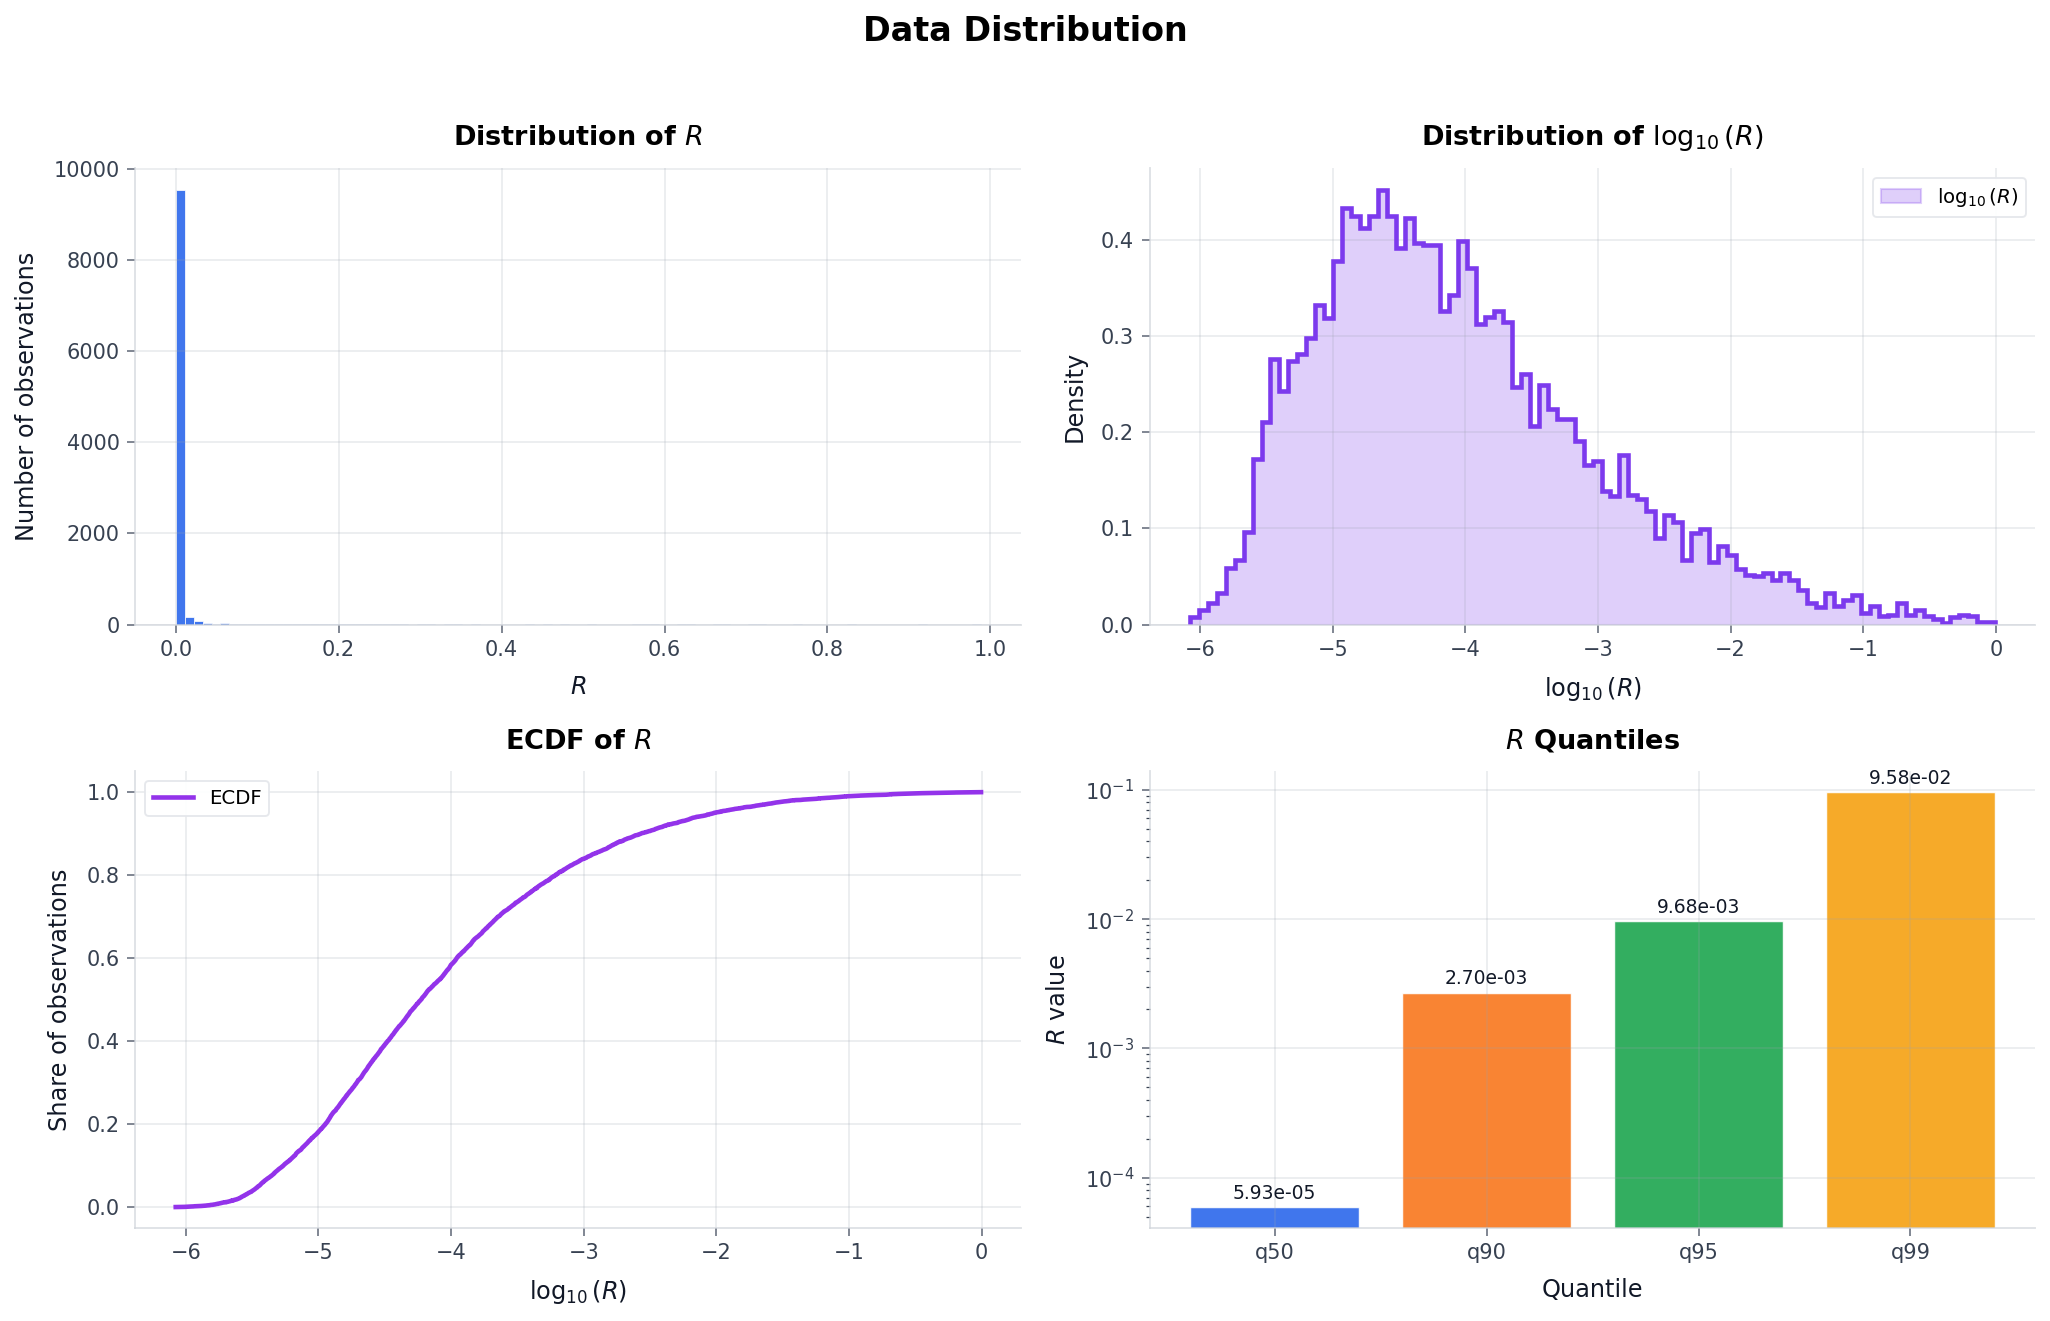

In [478]:
display(df[["R", "T"]].describe(percentiles=[0.01, 0.5, 0.9, 0.99]))

R_values = df["R"].to_numpy()
log_R_values = log10_safe(R_values)

fig, axes = plt.subplots(2, 2, figsize=(13.8, 8.6), dpi=150)
fig.suptitle("Data Distribution", fontsize=16, fontweight="semibold", y=1.02)

axes[0, 0].hist(
    R_values,
    bins=90,
    color=COLORS["train"],
    alpha=0.88,
    edgecolor="white",
    linewidth=0.4,
)
polish_axes(
    axes[0, 0],
    "Distribution of $R$",
    "$R$",
    "Number of observations",
)

plot_density_hist(
    axes[0, 1],
    log_R_values,
    bins=90,
    color=COLORS["purple"],
    label=r"$\log_{10}(R)$",
    alpha=0.24,
)
polish_axes(
    axes[0, 1],
    r"Distribution of $\log_{10}(R)$",
    r"$\log_{10}(R)$",
    "Density",
    legend=True,
)

plot_ecdf(
    axes[1, 0],
    log_R_values,
    color=COLORS["lbfgs"],
    label="ECDF",
)
polish_axes(
    axes[1, 0],
    "ECDF of $R$",
    r"$\log_{10}(R)$",
    "Share of observations",
    legend=True,
)

quantile_levels = np.array([0.50, 0.90, 0.95, 0.99])
quantile_values = np.quantile(R_values, quantile_levels)

axes[1, 1].bar(
    [f"q{int(q * 100)}" for q in quantile_levels],
    quantile_values,
    color=[COLORS["train"], COLORS["valid"], COLORS["test"], COLORS["amber"]],
    alpha=0.88,
    edgecolor="white",
    linewidth=0.7,
)
axes[1, 1].set_yscale("log")
for i, val in enumerate(quantile_values):
    axes[1, 1].text(
        i,
        val * 1.08,
        f"{val:.2e}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#111827",
    )
polish_axes(
    axes[1, 1],
    "$R$ Quantiles",
    "Quantile",
    "$R$ value",
)

plt.tight_layout()
plt.show()

## Features, Target, Physical Parameters

In [479]:
def build_features(data: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    features = pd.DataFrame(index=data.index)

    features["omega_norm"] = data["omega"] / cfg.omega0
    features["sin_psi"] = np.sin(data["psi"])
    features["cos_psi"] = np.cos(data["psi"])

    phase_x = 2.0 * np.pi * data["delta_x"] / cfg.period_a
    features["sin_dx"] = np.sin(phase_x)
    features["cos_dx"] = np.cos(phase_x)

    features["dy_norm"] = data["delta_y"] / cfg.period_a

    features["Re_mu"] = data["Re_mu"]
    features["Im_mu"] = data["Im_mu"]

    return features


feature_cols = [
    "omega_norm", "sin_psi", "cos_psi",
    "sin_dx", "cos_dx", "dy_norm",
    "Re_mu", "Im_mu",
]

target_cols = ["Re_zeta1", "Im_zeta1", "Re_zeta2", "Im_zeta2"]

X_raw = build_features(df, cfg)[feature_cols]
y_raw = df[target_cols]

phys_cols = [
    "psi", "delta_y", "kappa",
    "Re_mu", "Im_mu",
    "Re_S", "Im_S", "Re_S1", "Im_S1", "Re_S2", "Im_S2",
    "R",
]
phys_raw = df[phys_cols]

print("X:", X_raw.shape)
print("y:", y_raw.shape)
print("Physics:", phys_raw.shape)

X: (10000, 8)
y: (10000, 4)
Physics: (10000, 12)


## Train / Validation / Test Split

Train: 7000
Validation: 1500
Test:  1500


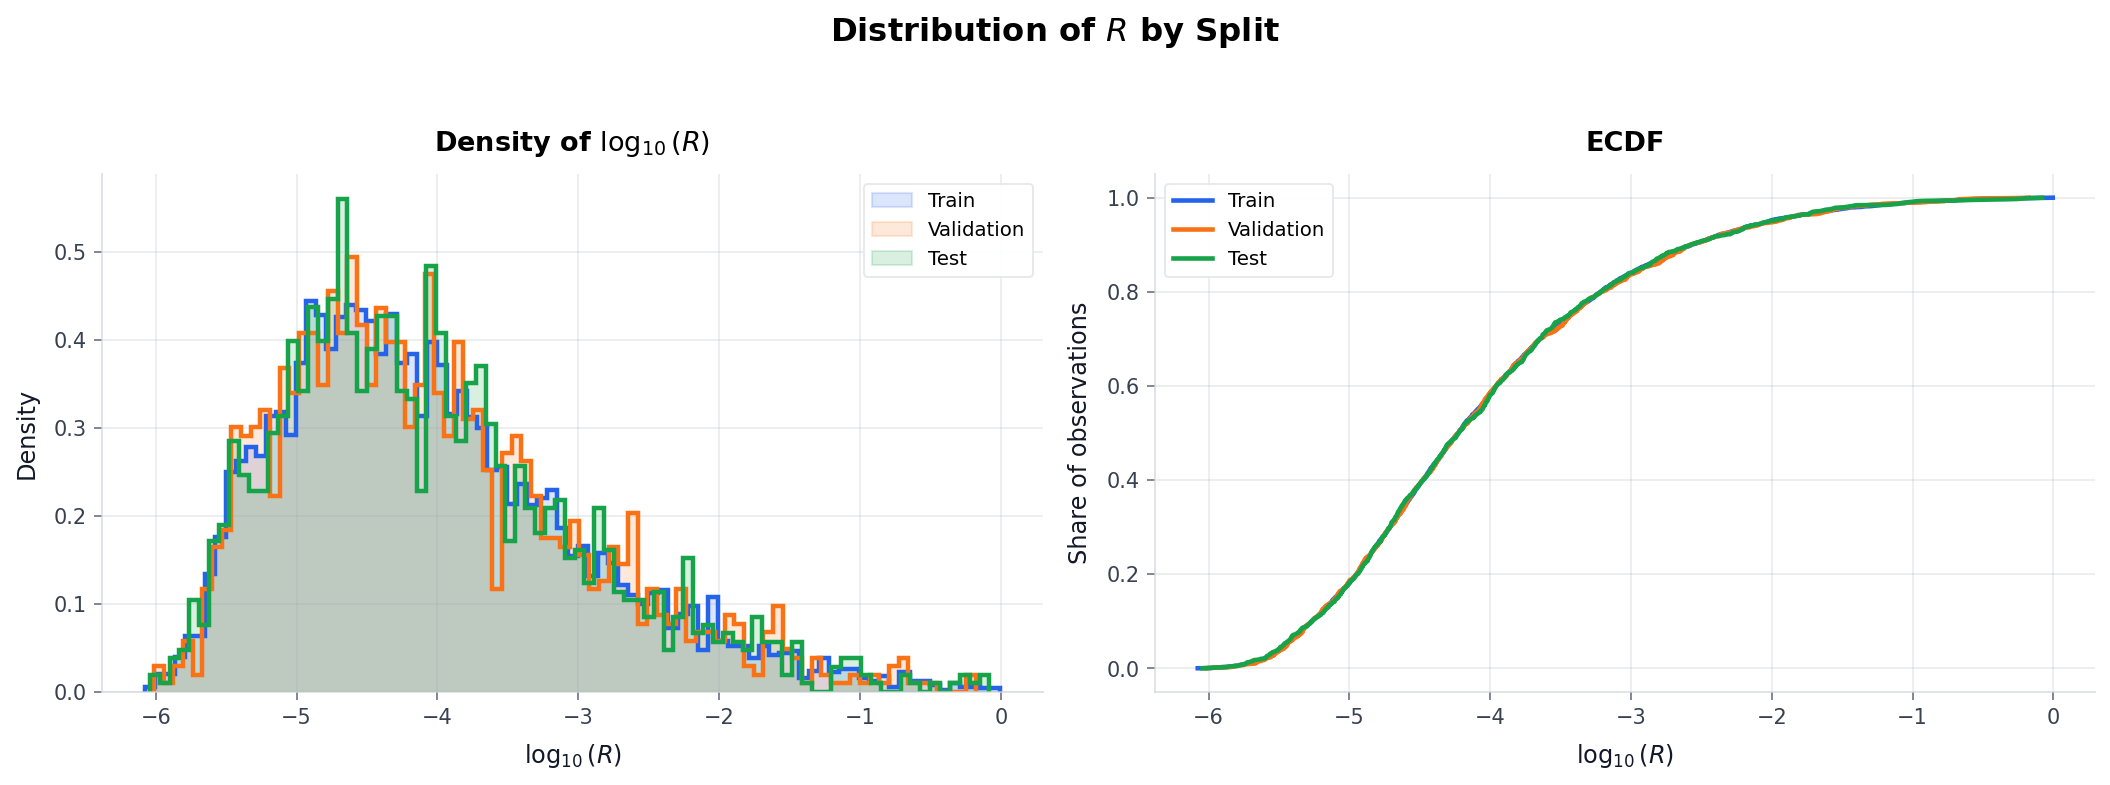

In [480]:
df_split = df.copy()
df_split["log_R"] = np.log1p(df_split["R"])

df_split["R_bin"] = pd.qcut(
    df_split["log_R"],
    q=cfg.n_strat_bins,
    labels=False,
    duplicates="drop",
)

idx = np.arange(len(df_split))
strat_labels = df_split["R_bin"].astype(int).values

idx_train, idx_temp = train_test_split(
    idx,
    test_size=cfg.valid_size + cfg.test_size,
    random_state=SEED,
    stratify=strat_labels,
)

temp_test_fraction = cfg.test_size / (cfg.valid_size + cfg.test_size)

idx_valid, idx_test = train_test_split(
    idx_temp,
    test_size=temp_test_fraction,
    random_state=SEED,
    stratify=strat_labels[idx_temp],
)

X_train_raw = X_raw.iloc[idx_train].copy()
X_valid_raw = X_raw.iloc[idx_valid].copy()
X_test_raw = X_raw.iloc[idx_test].copy()

y_train_raw = y_raw.iloc[idx_train].copy()
y_valid_raw = y_raw.iloc[idx_valid].copy()
y_test_raw = y_raw.iloc[idx_test].copy()

phys_train_raw = phys_raw.iloc[idx_train].copy()
phys_valid_raw = phys_raw.iloc[idx_valid].copy()
phys_test_raw = phys_raw.iloc[idx_test].copy()

print(f"Train: {len(idx_train)}")
print(f"Validation: {len(idx_valid)}")
print(f"Test:  {len(idx_test)}")

split_parts = {
    "train": phys_train_raw,
    "valid": phys_valid_raw,
    "test": phys_test_raw,
}

split_labels = {
    "train": "Train",
    "valid": "Validation",
    "test": "Test",
}

fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.0), dpi=150)
fig.suptitle("Distribution of $R$ by Split", fontsize=15.5, fontweight="semibold", y=1.04)

for name, part in split_parts.items():
    log_r = log10_safe(part["R"].to_numpy())
    color = SPLIT_COLORS[name]
    label = split_labels[name]

    plot_density_hist(
        axes[0],
        log_r,
        bins=85,
        color=color,
        label=label,
        alpha=0.16,
        linewidth=2.15,
    )

    plot_ecdf(
        axes[1],
        log_r,
        color=color,
        label=label,
        linewidth=2.2,
    )

polish_axes(
    axes[0],
    r"Density of $\log_{10}(R)$",
    r"$\log_{10}(R)$",
    "Density",
    legend=True,
)

polish_axes(
    axes[1],
    "ECDF",
    r"$\log_{10}(R)$",
    "Share of observations",
    legend=True,
)

plt.tight_layout()
plt.show()

## Noise Application

In [481]:
def add_gaussian_noise_to_targets(
    y: pd.DataFrame,
    noise_level: float,
    seed: int,
) -> pd.DataFrame:
    if noise_level <= 0:
        return y.copy()

    rng = np.random.default_rng(seed)
    y_noisy = y.copy()

    scale = y.std(axis=0, ddof=0).replace(0.0, 1.0)
    noise = rng.normal(loc=0.0, scale=1.0, size=y_noisy.shape)

    y_noisy.loc[:, :] = y_noisy.to_numpy() + noise_level * scale.to_numpy() * noise
    return y_noisy


if cfg.add_noise:
    y_train_raw = add_gaussian_noise_to_targets(
        y=y_train_raw,
        noise_level=cfg.noise_level,
        seed=cfg.noise_seed,
    )

## Normalization

In [482]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train_raw)
X_valid = x_scaler.transform(X_valid_raw)
X_test = x_scaler.transform(X_test_raw)

y_train = y_scaler.fit_transform(y_train_raw)
y_valid = y_scaler.transform(y_valid_raw)
y_test = y_scaler.transform(y_test_raw)

## Data Loader

In [483]:
def to_float_tensor(array_like) -> torch.Tensor:
    return torch.tensor(np.asarray(array_like), dtype=torch.float32)


X_train_t = to_float_tensor(X_train)
X_valid_t = to_float_tensor(X_valid)
X_test_t = to_float_tensor(X_test)

y_train_t = to_float_tensor(y_train)
y_valid_t = to_float_tensor(y_valid)
phys_train_t = to_float_tensor(phys_train_raw.values)
phys_valid_t = to_float_tensor(phys_valid_raw.values)
phys_test_t = to_float_tensor(phys_test_raw.values)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t, phys_train_t),
    batch_size=cfg.batch_size,
    shuffle=True,
    drop_last=False,
)

valid_loader = DataLoader(
    TensorDataset(X_valid_t, y_valid_t, phys_valid_t),
    batch_size=cfg.batch_size,
    shuffle=False,
    drop_last=False,
)

## PINN Architecture

In [484]:
class ForwardPINN(nn.Module):
    def __init__(
        self,
        input_dim: int,
        output_dim: int = 4,
        hidden_dim: int = 128,
        num_hidden_layers: int = 4,
        dropout: float = 0.0,
    ):
        super().__init__()

        layers = []
        in_dim = input_dim

        for _ in range(num_hidden_layers):
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(nn.SiLU())
            layers.append(nn.LayerNorm(hidden_dim))
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = hidden_dim

        layers.append(nn.Linear(hidden_dim, output_dim))
        self.net = nn.Sequential(*layers)

        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module: nn.Module) -> None:
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [485]:
model = ForwardPINN(
    input_dim=len(feature_cols),
    output_dim=len(target_cols),
    hidden_dim=cfg.hidden_dim,
    num_hidden_layers=cfg.num_hidden_layers,
    dropout=cfg.dropout,
).to(device)

print(model)
print(f"Number of Parameters: {sum(p.numel() for p in model.parameters()):,}")

ForwardPINN(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): SiLU()
    (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): SiLU()
    (5): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): SiLU()
    (8): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (9): Linear(in_features=128, out_features=128, bias=True)
    (10): SiLU()
    (11): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (12): Linear(in_features=128, out_features=4, bias=True)
  )
)
Number of Parameters: 52,228


## Physics

In [486]:
PHYS = {name: i for i, name in enumerate(phys_cols)}

y_mean_t = torch.tensor(y_scaler.mean_, dtype=torch.float32, device=device)
y_scale_t = torch.tensor(y_scaler.scale_, dtype=torch.float32, device=device)


def inverse_transform_y(y_scaled: torch.Tensor) -> torch.Tensor:
    return y_scaled * y_scale_t + y_mean_t


def as_complex(real: torch.Tensor, imag: torch.Tensor) -> torch.Tensor:
    return torch.complex(real, imag)


def unpack_zeta(y_physical: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    zeta1 = as_complex(y_physical[:, 0], y_physical[:, 1])
    zeta2 = as_complex(y_physical[:, 2], y_physical[:, 3])
    return zeta1, zeta2


def unpack_physics(phys_batch: torch.Tensor) -> dict[str, torch.Tensor]:
    phys_batch = phys_batch.to(device)

    return {
        "psi": phys_batch[:, PHYS["psi"]],
        "delta_y": phys_batch[:, PHYS["delta_y"]],
        "kappa": phys_batch[:, PHYS["kappa"]],
        "mu": as_complex(phys_batch[:, PHYS["Re_mu"]], phys_batch[:, PHYS["Im_mu"]]),
        "S": as_complex(phys_batch[:, PHYS["Re_S"]], phys_batch[:, PHYS["Im_S"]]),
        "S1": as_complex(phys_batch[:, PHYS["Re_S1"]], phys_batch[:, PHYS["Im_S1"]]),
        "S2": as_complex(phys_batch[:, PHYS["Re_S2"]], phys_batch[:, PHYS["Im_S2"]]),
        "R_true": phys_batch[:, PHYS["R"]],
    }


def project_R(R: torch.Tensor, cfg: Config) -> torch.Tensor:
    return torch.clamp(R, min=cfg.min_R, max=cfg.max_R)


def reflection_coefficient(y_physical: torch.Tensor, phys_batch: torch.Tensor, cfg: Config) -> torch.Tensor:
    zeta1, zeta2 = unpack_zeta(y_physical)
    phys = unpack_physics(phys_batch)

    ky = phys["kappa"] * torch.sin(phys["psi"])
    phase = torch.exp(1j * ky * phys["delta_y"])

    amplitude = zeta1 + zeta2 * phase
    denominator = 4.0 * cfg.period_a * phys["kappa"] ** 3 * torch.sin(phys["psi"])
    denominator = torch.clamp(denominator, min=1.0e-12)

    R0 = 1j * phys["mu"] * amplitude / denominator.to(torch.complex64)
    R = torch.abs(R0) ** 2

    return project_R(R.float(), cfg)


def physics_loss(y_physical: torch.Tensor, phys_batch: torch.Tensor) -> torch.Tensor:
    zeta1, zeta2 = unpack_zeta(y_physical)
    phys = unpack_physics(phys_batch)

    ky = phys["kappa"] * torch.sin(phys["psi"])
    exp1 = torch.ones_like(zeta1)
    exp2 = torch.exp(1j * ky * phys["delta_y"])

    term11 = phys["mu"] * phys["S"] * zeta1
    term12 = phys["mu"] * phys["S1"] * zeta2
    term21 = phys["mu"] * phys["S2"] * zeta1
    term22 = phys["mu"] * phys["S"] * zeta2

    res1 = zeta1 - exp1 - term11 - term12
    res2 = zeta2 - exp2 - term21 - term22

    scale1 = 1.0 + torch.abs(exp1) + torch.abs(term11) + torch.abs(term12)
    scale2 = 1.0 + torch.abs(exp2) + torch.abs(term21) + torch.abs(term22)

    res1_norm = res1 / scale1
    res2_norm = res2 / scale2

    return torch.mean(torch.abs(res1_norm) ** 2 + torch.abs(res2_norm) ** 2)


def coefficient_loss(y_physical: torch.Tensor, phys_batch: torch.Tensor, cfg: Config) -> torch.Tensor:
    phys = unpack_physics(phys_batch)

    R_pred = reflection_coefficient(y_physical, phys_batch, cfg)
    R_true = project_R(phys["R_true"], cfg)

    return torch.mean((torch.log1p(R_pred) - torch.log1p(R_true)) ** 2)


data_loss_fn = nn.SmoothL1Loss(beta=0.5)

## Training & Loss Functions

In [487]:
def clone_state_dict_to_cpu(model: nn.Module) -> dict[str, torch.Tensor]:
    return {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}


def total_loss_from_batch(
    model: nn.Module,
    bx: torch.Tensor,
    by: torch.Tensor,
    bphys: torch.Tensor,
) -> tuple[torch.Tensor, dict[str, float]]:
    pred_scaled = model(bx)
    pred_physical = inverse_transform_y(pred_scaled)

    loss_data = data_loss_fn(pred_scaled, by)
    loss_phys = physics_loss(pred_physical, bphys)
    loss_R = coefficient_loss(pred_physical, bphys, cfg)

    loss = loss_data + cfg.lambda_phys * loss_phys + cfg.lambda_R * loss_R

    metrics = {
        "loss": float(loss.detach().cpu()),
        "data": float(loss_data.detach().cpu()),
        "physics": float(loss_phys.detach().cpu()),
        "R": float(loss_R.detach().cpu()),
    }
    return loss, metrics


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer | None = None,
) -> dict[str, float]:
    train = optimizer is not None
    model.train(train)

    totals = {"loss": 0.0, "data": 0.0, "physics": 0.0, "R": 0.0}
    n_obs = 0

    for bx, by, bphys in loader:
        bx = bx.to(device)
        by = by.to(device)
        bphys = bphys.to(device)

        if train:
            optimizer.zero_grad(set_to_none=True)

        loss, metrics = total_loss_from_batch(model, bx, by, bphys)

        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

        batch_size = bx.shape[0]
        for key in totals:
            totals[key] += metrics[key] * batch_size
        n_obs += batch_size

    return {key: value / n_obs for key, value in totals.items()}


def evaluate_loader(model: nn.Module, loader: DataLoader) -> dict[str, float]:
    with torch.no_grad():
        return run_epoch(model, loader, optimizer=None)

## Training AdamW

In [488]:
history = []
lbfgs_trace = []
checkpoint = None
model_was_loaded = False

if cfg.load_existing_model:
    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Checkpoint was not found: {checkpoint_path}\n")

    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    best_state_dict = clone_state_dict_to_cpu(model)
    best_valid = float(checkpoint.get("metrics", {}).get("selected_valid_loss", np.nan))
    best_epoch = -1
    best_stage = checkpoint.get("metrics", {}).get("selected_stage", "loaded")
    model_was_loaded = True

    print(f"Loaded model: {checkpoint_path}")
    print(f"Selected stage: {best_stage}")
    if np.isfinite(best_valid):
        print(f"Saved validation loss: {best_valid:.6e}")
    print("Training skipped")
else:
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=60,
    )

    best_valid = float("inf")
    best_epoch = -1
    best_stage = "init"
    best_state_dict = clone_state_dict_to_cpu(model)
    bad_epochs = 0

    adam_bar = tqdm(
        range(1, cfg.max_epochs + 1),
        desc="AdamW",
        unit="epoch",
        dynamic_ncols=True,
    )

    for epoch in adam_bar:
        train_metrics = run_epoch(model, train_loader, optimizer=optimizer)
        valid_metrics = evaluate_loader(model, valid_loader)

        scheduler.step(valid_metrics["loss"])

        row = {
            "stage": "adam",
            "epoch": epoch,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"valid_{k}": v for k, v in valid_metrics.items()},
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)

        if valid_metrics["loss"] < best_valid - cfg.min_delta:
            best_valid = valid_metrics["loss"]
            best_epoch = epoch
            best_stage = "adam"
            best_state_dict = clone_state_dict_to_cpu(model)
            bad_epochs = 0
        else:
            bad_epochs += 1

        adam_bar.set_postfix(
            train=f"{train_metrics['loss']:.2e}",
            valid=f"{valid_metrics['loss']:.2e}",
            phys=f"{valid_metrics['physics']:.2e}",
            logR=f"{valid_metrics['R']:.2e}",
            lr=f"{optimizer.param_groups[0]['lr']:.1e}",
        )

        if bad_epochs >= cfg.patience:
            tqdm.write(f"Stopping at Epoch {epoch}. Best Epoch: {best_epoch}")
            break

    model.load_state_dict(best_state_dict)
    print(f"Best Adam Validation Loss: {best_valid:.6e} at Epoch {best_epoch}")

history_df = pd.DataFrame(history)

Loaded model: saved_models\noise_3\forward_N10k_h128x4_bs256_ep2000_lr0p001_phys1_R0p3.pt
Selected stage: adam
Saved validation loss: 5.430194e-03
Training skipped


## Plot AdamW

In [489]:
adam_history = history_df[history_df["stage"] == "adam"].copy() if "stage" in history_df.columns else pd.DataFrame()

if len(adam_history) == 0:
    print("AdamW plot skipped")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.0), dpi=150)
    fig.suptitle("Training AdamW", fontsize=15.5, fontweight="semibold", y=1.04)

    epoch = adam_history["epoch"].to_numpy()
    train_loss = adam_history["train_loss"].to_numpy()
    valid_loss = adam_history["valid_loss"].to_numpy()

    axes[0].plot(epoch, train_loss, color=COLORS["train"], alpha=0.22, linewidth=1.0)
    axes[0].plot(epoch, valid_loss, color=COLORS["valid"], alpha=0.22, linewidth=1.0)
    axes[0].plot(epoch, smooth_series(train_loss, 35), color=COLORS["train"], linewidth=2.4, label="Train loss")
    axes[0].plot(epoch, smooth_series(valid_loss, 35), color=COLORS["valid"], linewidth=2.4, label="Validation loss")
    axes[0].axvline(
        adam_history.loc[adam_history["valid_loss"].idxmin(), "epoch"],
        color=COLORS["gray"],
        linestyle="--",
        linewidth=1.2,
        alpha=0.75,
        label="Best validation",
    )
    axes[0].set_yscale("log")
    polish_axes(axes[0], "Total loss", "Epoch", "Loss", legend=True)

    component_specs = [
        ("valid_data", "Data", COLORS["data"]),
        ("valid_physics", "Physics", COLORS["physics"]),
        ("valid_R", "Reflection", COLORS["reflection"]),
    ]

    for col, label, color in component_specs:
        values = adam_history[col].to_numpy()
        axes[1].plot(epoch, values, color=color, alpha=0.20, linewidth=1.0)
        axes[1].plot(epoch, smooth_series(values, 35), color=color, linewidth=2.2, label=label)

    axes[1].set_yscale("log")
    polish_axes(axes[1], "Validation loss", "Epoch", "Loss", legend=True)

    plt.tight_layout()
    plt.show()

    display(adam_history.tail())

AdamW plot skipped


## Training L-BFGS

In [490]:
if cfg.use_lbfgs and not cfg.load_existing_model:
    model.load_state_dict(best_state_dict)
    model.train()

    X_train_full = X_train_t.to(device)
    y_train_full = y_train_t.to(device)
    phys_train_full = phys_train_t.to(device)

    lbfgs = torch.optim.LBFGS(
        model.parameters(),
        lr=cfg.lbfgs_lr,
        max_iter=cfg.lbfgs_max_iter,
        max_eval=cfg.lbfgs_max_eval,
        history_size=cfg.lbfgs_history_size,
        tolerance_grad=cfg.lbfgs_tolerance_grad,
        tolerance_change=cfg.lbfgs_tolerance_change,
        line_search_fn="strong_wolfe",
    )

    closure_calls = [0]

    lbfgs_best_valid = [best_valid]
    lbfgs_best_eval = [None]
    lbfgs_best_state_dict = [None]

    lbfgs_bar = tqdm(
        total=cfg.lbfgs_max_eval,
        desc="L-BFGS",
        unit="eval",
        dynamic_ncols=True,
    )

    def closure():
        lbfgs.zero_grad(set_to_none=True)

        loss, metrics = total_loss_from_batch(
            model,
            X_train_full,
            y_train_full,
            phys_train_full,
        )
        loss.backward()

        closure_calls[0] += 1

        should_log_train = closure_calls[0] == 1 or closure_calls[0] % cfg.lbfgs_log_every == 0
        should_log_valid = closure_calls[0] == 1 or closure_calls[0] % cfg.lbfgs_valid_log_every == 0

        valid_snapshot = {
            "loss": np.nan,
            "data": np.nan,
            "physics": np.nan,
            "R": np.nan,
        }

        if should_log_valid:
            model.eval()
            valid_snapshot = evaluate_loader(model, valid_loader)
            model.train()

            if valid_snapshot["loss"] < lbfgs_best_valid[0] - cfg.min_delta:
                lbfgs_best_valid[0] = valid_snapshot["loss"]
                lbfgs_best_eval[0] = closure_calls[0]
                lbfgs_best_state_dict[0] = clone_state_dict_to_cpu(model)

        if should_log_train or should_log_valid:
            lbfgs_trace.append({
                "eval": closure_calls[0],
                "train_loss": metrics["loss"],
                "train_data": metrics["data"],
                "train_physics": metrics["physics"],
                "train_R": metrics["R"],
                "valid_loss": valid_snapshot["loss"],
                "valid_data": valid_snapshot["data"],
                "valid_physics": valid_snapshot["physics"],
                "valid_R": valid_snapshot["R"],
            })

        lbfgs_bar.update(1)

        if closure_calls[0] == 1 or closure_calls[0] % 10 == 0:
            postfix = {
                "train": f"{metrics['loss']:.2e}",
                "phys": f"{metrics['physics']:.2e}",
                "logR": f"{metrics['R']:.2e}",
            }
            if should_log_valid:
                postfix["valid"] = f"{valid_snapshot['loss']:.2e}"
            lbfgs_bar.set_postfix(**postfix)

        return loss

    lbfgs.step(closure)
    lbfgs_bar.close()

    train_metrics = evaluate_loader(model, train_loader)
    valid_metrics = evaluate_loader(model, valid_loader)

    row = {
        "stage": "lbfgs",
        "epoch": closure_calls[0],
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"valid_{k}": v for k, v in valid_metrics.items()},
        "lr": cfg.lbfgs_lr,
    }
    history.append(row)

    print(f"L-BFGS Final Train Loss: {train_metrics['loss']:.6e}")
    print(f"L-BFGS Final Valid Loss: {valid_metrics['loss']:.6e}")

    if valid_metrics["loss"] < lbfgs_best_valid[0] - cfg.min_delta:
        lbfgs_best_valid[0] = valid_metrics["loss"]
        lbfgs_best_eval[0] = closure_calls[0]
        lbfgs_best_state_dict[0] = clone_state_dict_to_cpu(model)

    if lbfgs_best_state_dict[0] is not None:
        best_valid = lbfgs_best_valid[0]
        best_epoch = lbfgs_best_eval[0]
        best_stage = "lbfgs"
        best_state_dict = lbfgs_best_state_dict[0]
    else:
        print("L-BFGS did not improve")

elif cfg.load_existing_model:
    print("L-BFGS skipped")

elif not cfg.use_lbfgs:
    print("L-BFGS skipped")

model.load_state_dict(best_state_dict)
history_df = pd.DataFrame(history)

print(f"\nSelected Stage: {best_stage}")
print(f"Best Validation Loss After All Stages: {best_valid:.6e}")

L-BFGS skipped

Selected Stage: adam
Best Validation Loss After All Stages: 5.430194e-03


## Plot L-BFGS

In [491]:
lbfgs_trace_df = pd.DataFrame(lbfgs_trace)

if len(lbfgs_trace_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.0), dpi=150)
    fig.suptitle("Training L-BFGS", fontsize=15.5, fontweight="semibold", y=1.04)

    valid_trace = lbfgs_trace_df.dropna(subset=["valid_loss"])

    axes[0].plot(
        lbfgs_trace_df["eval"],
        lbfgs_trace_df["train_loss"],
        label="Train loss",
        color=COLORS["lbfgs"],
        linewidth=2.2,
    )

    if len(valid_trace) > 0:
        axes[0].plot(
            valid_trace["eval"],
            valid_trace["valid_loss"],
            label="Validation loss",
            color=COLORS["valid"],
            linewidth=2.2,
            marker="o",
            markersize=3.5,
            markerfacecolor="white",
            markeredgewidth=1.0,
        )

        best_lbfgs_row = valid_trace.loc[valid_trace["valid_loss"].idxmin()]
        axes[0].axvline(
            best_lbfgs_row["eval"],
            color=COLORS["gray"],
            linestyle="--",
            linewidth=1.4,
            alpha=0.75,
            label="Best L-BFGS validation",
        )

    axes[0].set_yscale("log")
    polish_axes(axes[0], "Total loss", "Evaluation", "Loss", legend=True)

    train_components = [
        ("train_data", "Train data", COLORS["data"]),
        ("train_physics", "Train physics", COLORS["physics"]),
        ("train_R", "Train reflection", COLORS["reflection"]),
    ]

    for col, label, color in train_components:
        axes[1].plot(
            lbfgs_trace_df["eval"],
            lbfgs_trace_df[col],
            color=color,
            linewidth=2.0,
            label=label,
        )

    if len(valid_trace) > 0:
        valid_components = [
            ("valid_data", "Validation data", COLORS["data"]),
            ("valid_physics", "Validation physics", COLORS["physics"]),
            ("valid_R", "Validation reflection", COLORS["reflection"]),
        ]

        for col, label, color in valid_components:
            axes[1].plot(
                valid_trace["eval"],
                valid_trace[col],
                linestyle="--",
                color=color,
                linewidth=1.7,
                alpha=0.85,
                marker="o",
                markersize=2.8,
                label=label,
            )

    axes[1].set_yscale("log")
    polish_axes(axes[1], "Loss components", "Evaluation", "Loss", legend=True)
    axes[1].legend(ncol=2, fontsize=8.5)

    plt.tight_layout()
    plt.show()

else:
    print(f"L-BFGS plot skipped")

display(history_df.tail())

L-BFGS plot skipped


""


## Test Prediction

In [492]:
@torch.no_grad()
def predict_dataset(model, X_t: torch.Tensor, batch_size: int = 4096) -> np.ndarray:
    model.eval()
    preds = []

    loader = DataLoader(TensorDataset(X_t), batch_size=batch_size, shuffle=False)
    for (bx,) in loader:
        bx = bx.to(device)
        pred_scaled = model(bx)
        pred_physical = inverse_transform_y(pred_scaled)
        preds.append(pred_physical.cpu().numpy())

    return np.vstack(preds)


@torch.no_grad()
def predict_R_dataset(
    model,
    X_t: torch.Tensor,
    phys_t: torch.Tensor,
    batch_size: int = 4096,
) -> np.ndarray:
    model.eval()
    preds = []

    loader = DataLoader(TensorDataset(X_t, phys_t), batch_size=batch_size, shuffle=False)
    for bx, bphys in loader:
        bx = bx.to(device)
        bphys = bphys.to(device)

        pred_scaled = model(bx)
        pred_physical = inverse_transform_y(pred_scaled)
        R_pred = reflection_coefficient(pred_physical, bphys, cfg)

        preds.append(R_pred.cpu().numpy())

    return np.concatenate(preds)


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }


y_pred_test = predict_dataset(model, X_test_t)
R_pred_test = predict_R_dataset(model, X_test_t, phys_test_t)

y_true_test = y_test_raw.values
R_true_test = phys_test_raw["R"].values

## Metrics

In [493]:
rows = []

for i, col in enumerate(target_cols):
    metrics = regression_metrics(y_true_test[:, i], y_pred_test[:, i])
    rows.append({
        "Target": col,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "R2": metrics["R2"],
    })

metrics_R = regression_metrics(R_true_test, R_pred_test)
metrics_logR = regression_metrics(np.log1p(R_true_test), np.log1p(R_pred_test))

rows.append({
    "Target": "R",
    "MAE": metrics_R["MAE"],
    "RMSE": metrics_R["RMSE"],
    "R2": metrics_R["R2"],
})
rows.append({
    "Target": "log1p(R)",
    "MAE": metrics_logR["MAE"],
    "RMSE": metrics_logR["RMSE"],
    "R2": metrics_logR["R2"],
})

metrics_df = pd.DataFrame(rows)
display(metrics_df)

,Target,MAE,RMSE,R2
0,Re_zeta1,0.001649,0.012183,0.891237
1,Im_zeta1,0.001843,0.007056,0.988487
2,Re_zeta2,0.002168,0.009326,0.987743
3,Im_zeta2,0.003048,0.009423,0.998062
4,R,0.000454,0.008059,0.966020
5,log1p(R),0.000281,0.004731,0.981146


## Prediction Visualization, Error Plot

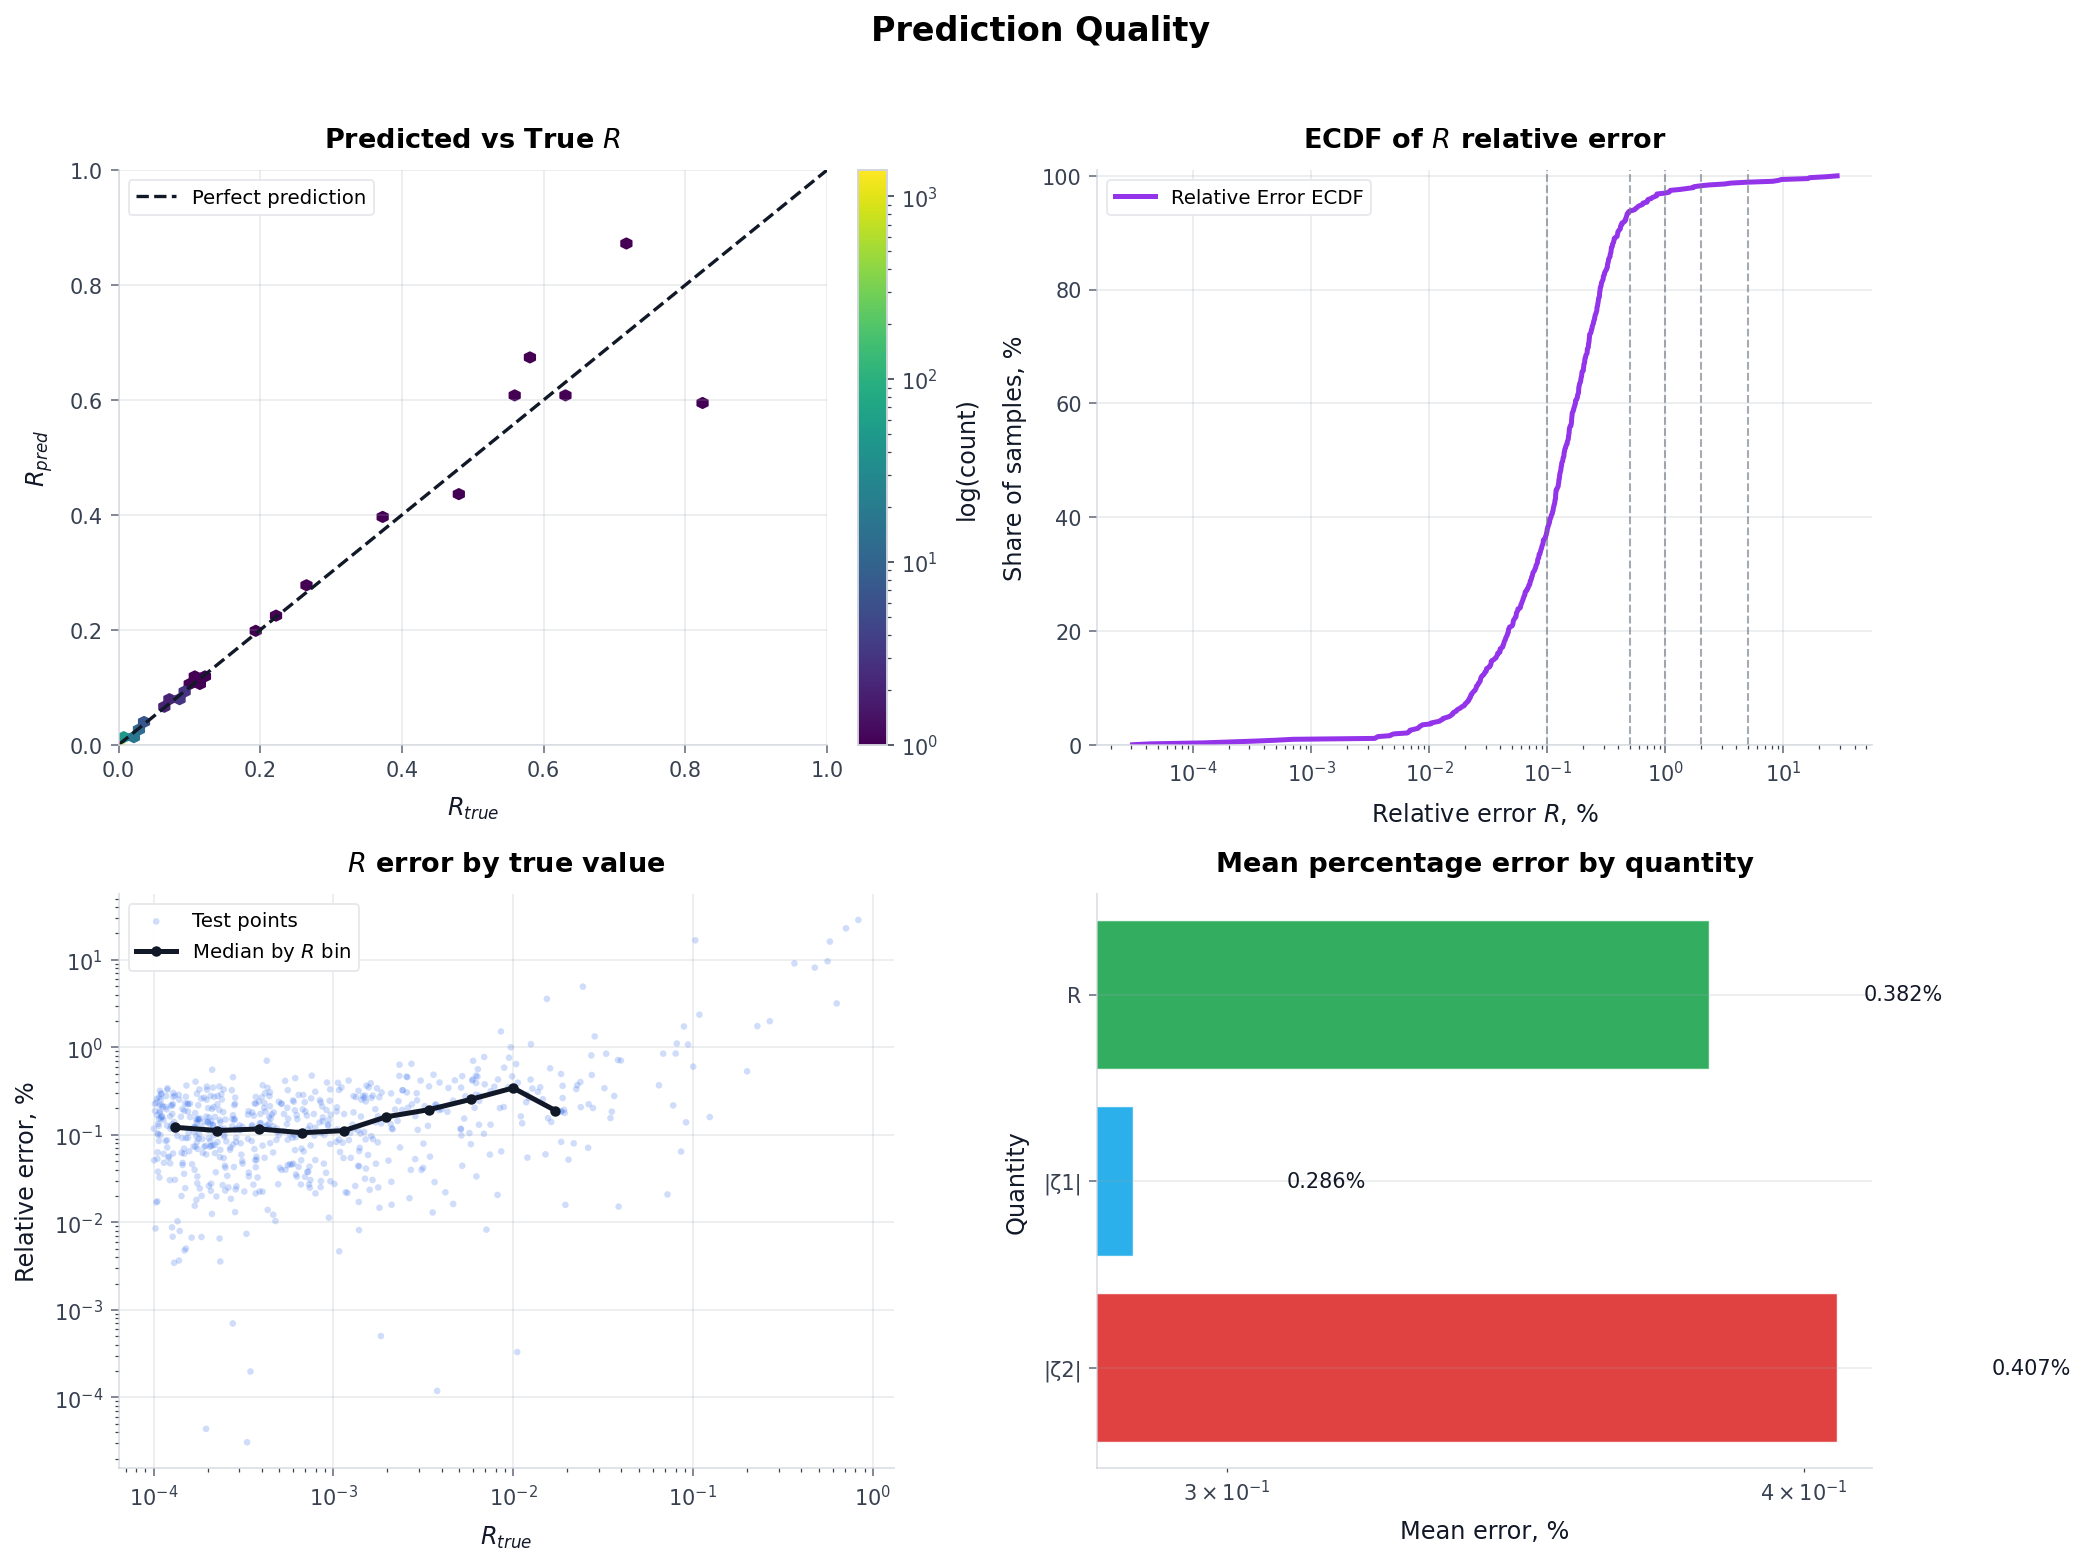

In [494]:
rng = np.random.default_rng(SEED)
plot_size = min(cfg.plot_sample_size, len(R_true_test))
plot_idx = rng.choice(len(R_true_test), size=plot_size, replace=False)

error_R = R_pred_test - R_true_test
abs_error_R = np.abs(error_R)

mask_rel = R_true_test >= cfg.relative_error_min_R
rel_error_R_pct_all = np.full_like(R_true_test, np.nan, dtype=float)
rel_error_R_pct_all[mask_rel] = 100.0 * abs_error_R[mask_rel] / R_true_test[mask_rel]

zeta1_true = y_true_test[:, 0] + 1j * y_true_test[:, 1]
zeta1_pred = y_pred_test[:, 0] + 1j * y_pred_test[:, 1]
zeta2_true = y_true_test[:, 2] + 1j * y_true_test[:, 3]
zeta2_pred = y_pred_test[:, 2] + 1j * y_pred_test[:, 3]

zeta_eps = 1e-12
zeta1_error_pct = 100.0 * np.abs(zeta1_pred - zeta1_true) / np.maximum(np.abs(zeta1_true), zeta_eps)
zeta2_error_pct = 100.0 * np.abs(zeta2_pred - zeta2_true) / np.maximum(np.abs(zeta2_true), zeta_eps)

fig, axes = plt.subplots(2, 2, figsize=(14.0, 10.2), dpi=150)
fig.suptitle("Prediction Quality", fontsize=16, fontweight="semibold", y=1.02)

hb = axes[0, 0].hexbin(
    R_true_test[plot_idx],
    R_pred_test[plot_idx],
    gridsize=58,
    bins="log",
    mincnt=1,
    cmap="viridis",
)
axes[0, 0].plot([0.0, 1.0], [0.0, 1.0], linestyle="--", linewidth=1.6, color=COLORS["ideal"], label="Perfect prediction")
axes[0, 0].set_xlim(0.0, 1.0)
axes[0, 0].set_ylim(0.0, 1.0)
polish_axes(
    axes[0, 0],
    "Predicted vs True $R$",
    r"$R_{true}$",
    r"$R_{pred}$",
    legend=True,
)
cb = fig.colorbar(hb, ax=axes[0, 0], fraction=0.046, pad=0.04)
cb.set_label("log(count)", labelpad=8)

rel_errors = rel_error_R_pct_all[np.isfinite(rel_error_R_pct_all)]
rel_sorted = np.sort(rel_errors)
rel_ecdf = np.linspace(0.0, 100.0, len(rel_sorted), endpoint=True)

axes[0, 1].plot(
    rel_sorted,
    rel_ecdf,
    color=COLORS["lbfgs"],
    linewidth=2.4,
    label="Relative Error ECDF",
)
for threshold in [0.1, 0.5, 1.0, 2.0, 5.0]:
    if threshold <= np.nanmax(rel_sorted):
        axes[0, 1].axvline(threshold, linestyle="--", linewidth=1.0, alpha=0.6, color=COLORS["gray"])
axes[0, 1].set_xscale("log")
axes[0, 1].set_ylim(0, 101)
polish_axes(
    axes[0, 1],
    "ECDF of $R$ relative error",
    "Relative error $R$, %",
    "Share of samples, %",
    legend=True,
)

plot_mask = np.isfinite(rel_error_R_pct_all[plot_idx])
axes[1, 0].scatter(
    R_true_test[plot_idx][plot_mask],
    rel_error_R_pct_all[plot_idx][plot_mask],
    s=10,
    alpha=0.22,
    color=COLORS["train"],
    edgecolors="none",
    label="Test points",
)

bins_for_trend = np.geomspace(max(cfg.relative_error_min_R, 1e-8), 1.0, 18)
bin_ids = np.digitize(R_true_test[mask_rel], bins_for_trend)
trend_x, trend_y = [], []
for b in range(1, len(bins_for_trend)):
    m = bin_ids == b
    if np.sum(m) >= 20:
        trend_x.append(np.sqrt(bins_for_trend[b - 1] * bins_for_trend[b]))
        trend_y.append(np.nanmedian(rel_error_R_pct_all[mask_rel][m]))

if len(trend_x) > 0:
    axes[1, 0].plot(
        trend_x,
        trend_y,
        color=COLORS["ideal"],
        linewidth=2.4,
        marker="o",
        markersize=4,
        label="Median by $R$ bin",
    )

axes[1, 0].set_xscale("log")
axes[1, 0].set_yscale("log")
polish_axes(
    axes[1, 0],
    "$R$ error by true value",
    r"$R_{true}$",
    "Relative error, %",
    legend=True,
)

quantities = ["R", r"|ζ1|", r"|ζ2|"]
mean_errors = np.array([
    np.nanmean(rel_error_R_pct_all),
    np.mean(zeta1_error_pct),
    np.mean(zeta2_error_pct),
])

bar_colors = [COLORS["reflection"], COLORS["data"], COLORS["physics"]]
axes[1, 1].barh(
    quantities[::-1],
    mean_errors[::-1],
    color=bar_colors[::-1],
    alpha=0.88,
    edgecolor="white",
    linewidth=0.7,
)
axes[1, 1].set_xscale("log")

for i, value in enumerate(mean_errors[::-1]):
    axes[1, 1].text(
        value * 1.08,
        i,
        f"{value:.3g}%",
        va="center",
        ha="left",
        fontsize=10,
        color="#111827",
    )

polish_axes(
    axes[1, 1],
    "Mean percentage error by quantity",
    "Mean error, %",
    "Quantity",
)

plt.tight_layout()
plt.show()

## Relative Error

,threshold_percent,share_of_test_points_percent
0,0.1,37.996820
1,0.5,93.799682
2,1.0,96.979332
3,2.0,98.251192
4,5.0,98.887122


,R_range,count,mean_error_percent,share_error_below_1pct
0,"$[10^{-4}, 10^{-3}]$",389,0.133546,100.000000
1,"$(10^{-3}, 10^{-2}]$",166,0.217147,99.397590
2,"$(10^{-2}, 10^{-1}]$",60,0.508814,88.333333
3,"$(10^{-1}, 1]$",14,8.678371,21.428571


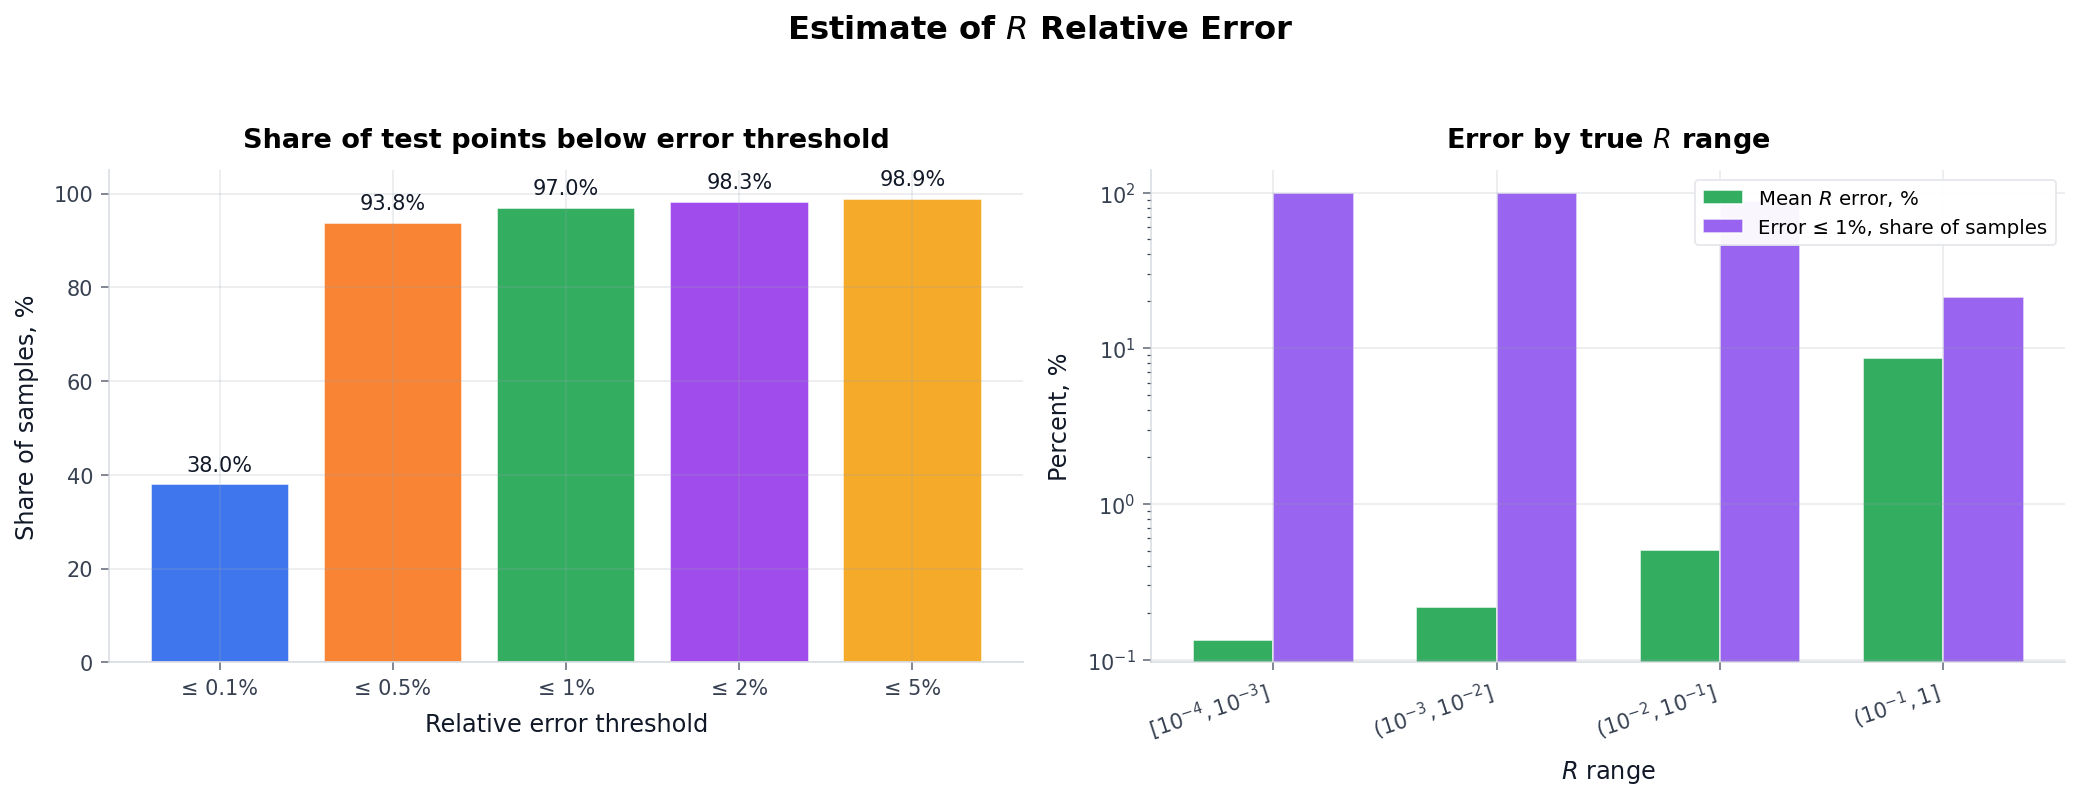

In [495]:
rel_R = rel_error_R_pct_all[np.isfinite(rel_error_R_pct_all)]

thresholds = np.array([0.1, 0.5, 1.0, 2.0, 5.0])
coverage = np.array([
    100.0 * np.mean(rel_R <= threshold)
    for threshold in thresholds
])

coverage_df = pd.DataFrame({
    "threshold_percent": thresholds,
    "share_of_test_points_percent": coverage,
})

error_by_R = pd.DataFrame({
    "R_true": R_true_test[mask_rel],
    "relative_error_percent": rel_error_R_pct_all[mask_rel],
})

R_bins = [cfg.relative_error_min_R, 1e-3, 1e-2, 1e-1, np.inf]
R_bin_labels = [
    r"$[10^{-4}, 10^{-3}]$",
    r"$(10^{-3}, 10^{-2}]$",
    r"$(10^{-2}, 10^{-1}]$",
    r"$(10^{-1}, 1]$",
]

error_by_R["R_range"] = pd.cut(
    error_by_R["R_true"],
    bins=R_bins,
    labels=R_bin_labels,
    include_lowest=True,
)

range_summary = (
    error_by_R
    .groupby("R_range", observed=True)
    .agg(
        count=("relative_error_percent", "size"),
        mean_error_percent=("relative_error_percent", "mean"),
        share_error_below_1pct=("relative_error_percent", lambda x: 100.0 * np.mean(x <= 1.0)),
    )
    .reset_index()
)

display(coverage_df)
display(range_summary)

fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.1), dpi=150)
fig.suptitle(r"Estimate of $R$ Relative Error", fontsize=15.5, fontweight="semibold", y=1.04)

bars = axes[0].bar(
    [f"≤ {x:g}%" for x in thresholds],
    coverage,
    color=[COLORS["train"], COLORS["valid"], COLORS["test"], COLORS["lbfgs"], COLORS["amber"]],
    alpha=0.88,
    edgecolor="white",
    linewidth=0.8,
)
axes[0].set_ylim(0, 105)

for bar, value in zip(bars, coverage):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        min(value + 2.0, 103),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#111827",
    )

polish_axes(
    axes[0],
    "Share of test points below error threshold",
    "Relative error threshold",
    "Share of samples, %",
)

x = np.arange(len(range_summary))
width = 0.36

axes[1].bar(
    x - width / 2,
    range_summary["mean_error_percent"],
    width=width,
    color=COLORS["reflection"],
    alpha=0.88,
    edgecolor="white",
    linewidth=0.8,
    label=r"Mean $R$ error, %",
)

axes[1].bar(
    x + width / 2,
    range_summary["share_error_below_1pct"],
    width=width,
    color=COLORS["purple"],
    alpha=0.78,
    edgecolor="white",
    linewidth=0.8,
    label="Error ≤ 1%, share of samples",
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(range_summary["R_range"].astype(str), rotation=18, ha="right")
axes[1].set_yscale("log")

polish_axes(
    axes[1],
    r"Error by true $R$ range",
    r"$R$ range",
    "Percent, %",
    legend=True,
)

plt.tight_layout()
plt.show()

## Physics Loss

In [496]:
@torch.no_grad()
def physics_loss_dataset(model, X_t: torch.Tensor, phys_t: torch.Tensor, batch_size: int = 4096) -> float:
    model.eval()
    total = 0.0
    n_obs = 0

    loader = DataLoader(TensorDataset(X_t, phys_t), batch_size=batch_size, shuffle=False)
    for bx, bphys in loader:
        bx = bx.to(device)
        bphys = bphys.to(device)

        pred_scaled = model(bx)
        pred_physical = inverse_transform_y(pred_scaled)
        loss = physics_loss(pred_physical, bphys)

        total += loss.item() * bx.shape[0]
        n_obs += bx.shape[0]

    return total / n_obs


test_phys_loss = physics_loss_dataset(model, X_test_t, phys_test_t)
print(f"Test Physics Loss: {test_phys_loss:.6e}")

Test Physics Loss: 5.511536e-05


## Save Model

In [497]:
def config_to_serializable_dict(cfg: Config) -> dict:
    result = {}
    for key, value in asdict(cfg).items():
        result[key] = str(value) if isinstance(value, Path) else value
    return result


model.load_state_dict(best_state_dict)

checkpoint = {
    "model_state_dict": best_state_dict,
    "config": config_to_serializable_dict(cfg),
    "feature_cols": feature_cols,
    "target_cols": target_cols,
    "phys_cols": phys_cols,
    "x_scaler_mean": x_scaler.mean_,
    "x_scaler_scale": x_scaler.scale_,
    "y_scaler_mean": y_scaler.mean_,
    "y_scaler_scale": y_scaler.scale_,
    "metrics": {
        "test_metrics": metrics_df.to_dict(orient="records"),
        "test_physics_loss": float(test_phys_loss),
        "selected_valid_loss": float(best_valid),
        "selected_stage": best_stage,
    },
    "noise": {
        "add_noise": cfg.add_noise,
        "noise_level": cfg.noise_level,
        "noise_percent": noise_percent,
        "noise_seed": cfg.noise_seed,
    },
    "n_objects": n_objects,
    "seed": SEED,
}

if model_was_loaded:
    print(f"Loaded model without overwriting: {checkpoint_path}")
elif cfg.save_model_after_training:
    torch.save(checkpoint, model_path)
    print(f"Saved model: {model_path}")
else:
    print("Model saving skipped")


Loaded model without overwriting: saved_models\noise_3\forward_N10k_h128x4_bs256_ep2000_lr0p001_phys1_R0p3.pt
